In [1]:
from typing import List

import modules.data_reader as dr
from modules.common import TimeSeries, TimeSeriesPlot, TimeSeriesPlotParams, MetricName, ModelType
from modules.time_series_pipeline import TimeSeriesPipeline

In [2]:
params: dr.InputParams = dr.InputParams(
    #reading
    data_directory='data/source_data',
    tickets_group='NDXT_3',
    file_extension='csv',
    time_column='datetime',
    data_columns=['open', 'close'],
    # processing
    missing_method='rolling',
    rolling_window_size=2,
    target_frequency='H',
    frequency_method='mean',
    anomaly_method='rolling',
    z_threshold=3.0,
    decompose_model='additive',
    decompose_period=24 * 7 * 4,  # дискретизация тренда по месяцам при условии наличия часовых наблюдений
    correlation_method='spearman',
    correlation_threshold=0.3,
    is_feature_selection=True,
    # generating
    cv_method='expanding',
    cv_frequency='M',
    models_types=['linear_regression', 'xgb_regressor', 'decompose'],
    validation_ratio=0.8,
    n_estimators=500,
    max_depth=[2,4,8],
    learning_rate=0.1,
    eval_metric='mae',
    early_stopping_rounds=20
)

plot_params: TimeSeriesPlotParams = TimeSeriesPlotParams(
    ticket_name='AAPL',
    data_column_name='close',
    metrics_names=[MetricName.fa_mape.value],
    models_types=[ModelType.xgb_regressor, ModelType.decompose]
)

In [3]:
# Инициализация временных рядов
time_series: List[TimeSeries] = (
    TimeSeriesPipeline.time_series_read_parallel(params=params)
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished


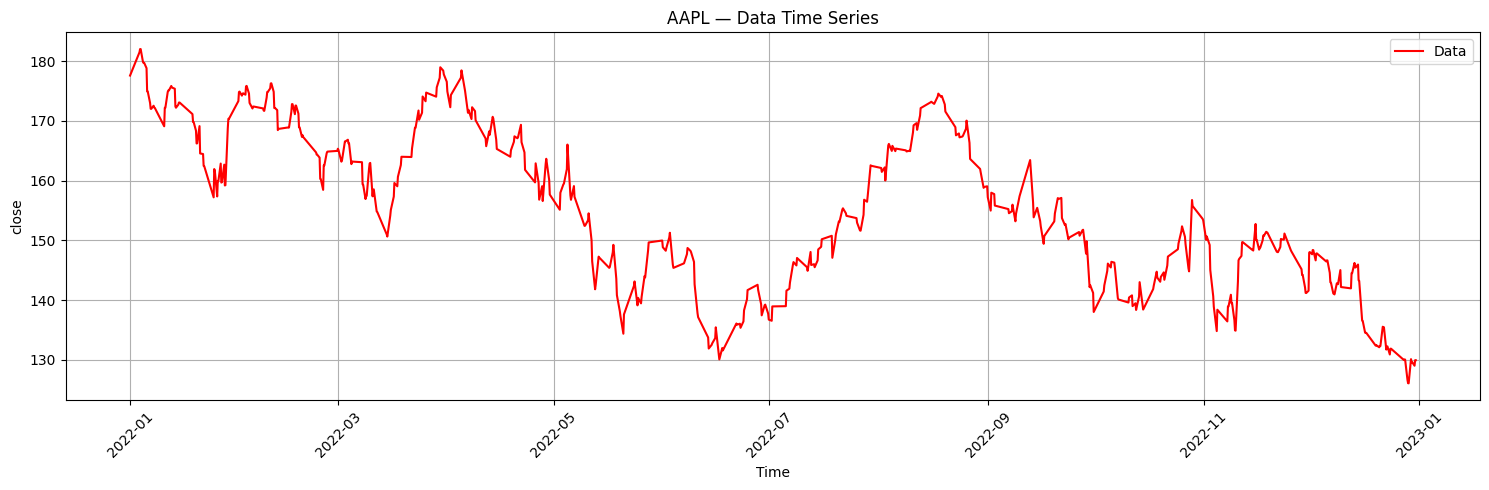

In [4]:
for ts in time_series:
    if ts.ticket_name == plot_params.ticket_name and ts.data_column_name == plot_params.data_column_name:
        TimeSeriesPlot.plot_source_data(time_series=ts)

In [5]:
# Подготовка данных временных рядов
time_series_process: List[TimeSeries] = (
    TimeSeriesPipeline.time_series_process_parallel(params=params, time_series=time_series)
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   6 | elapsed:    1.8s remaining:    3.7s
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    1.8s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:    1.8s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    1.9s finished


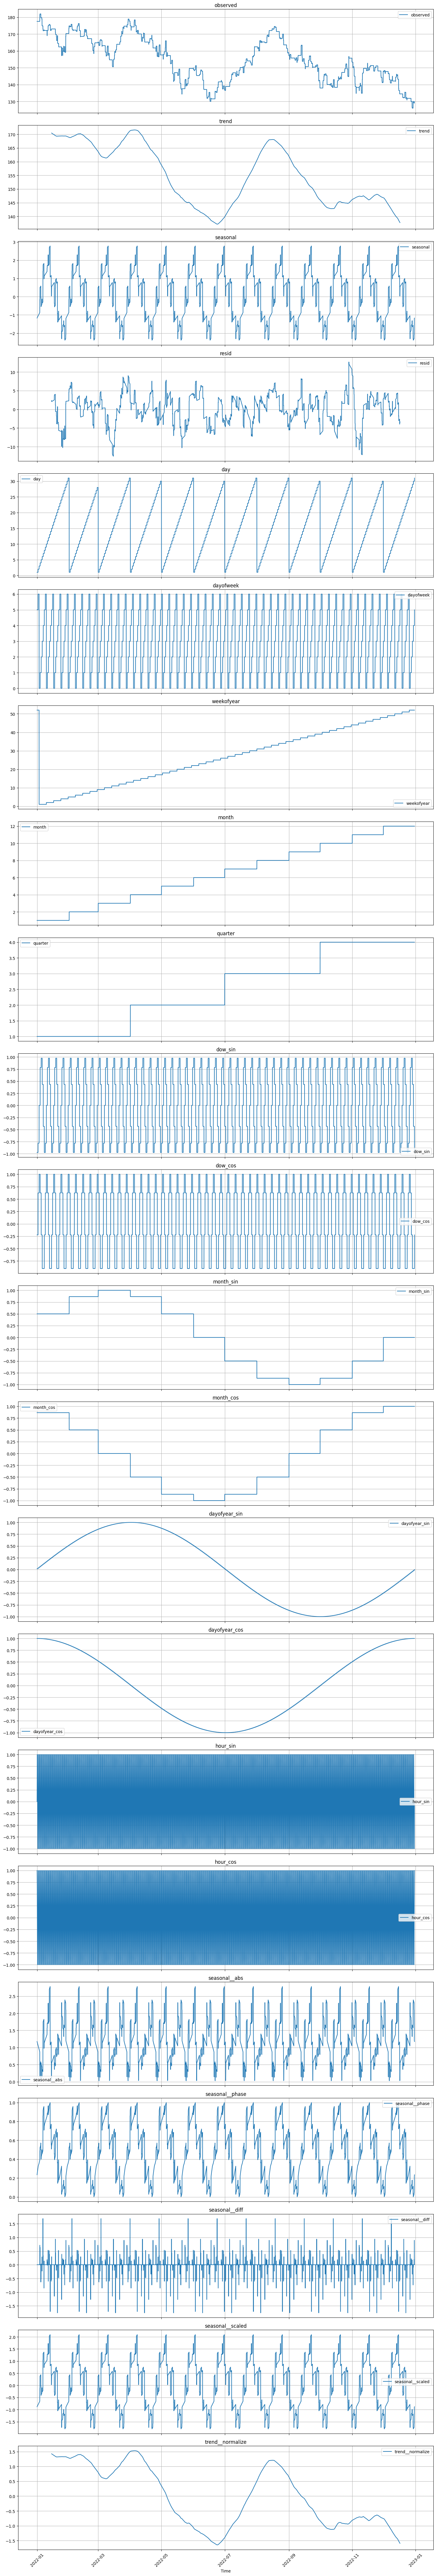

In [6]:
for ts in time_series_process:
    if ts.ticket_name == plot_params.ticket_name and ts.data_column_name == plot_params.data_column_name:
        TimeSeriesPlot.plot_processed_data(time_series=ts)

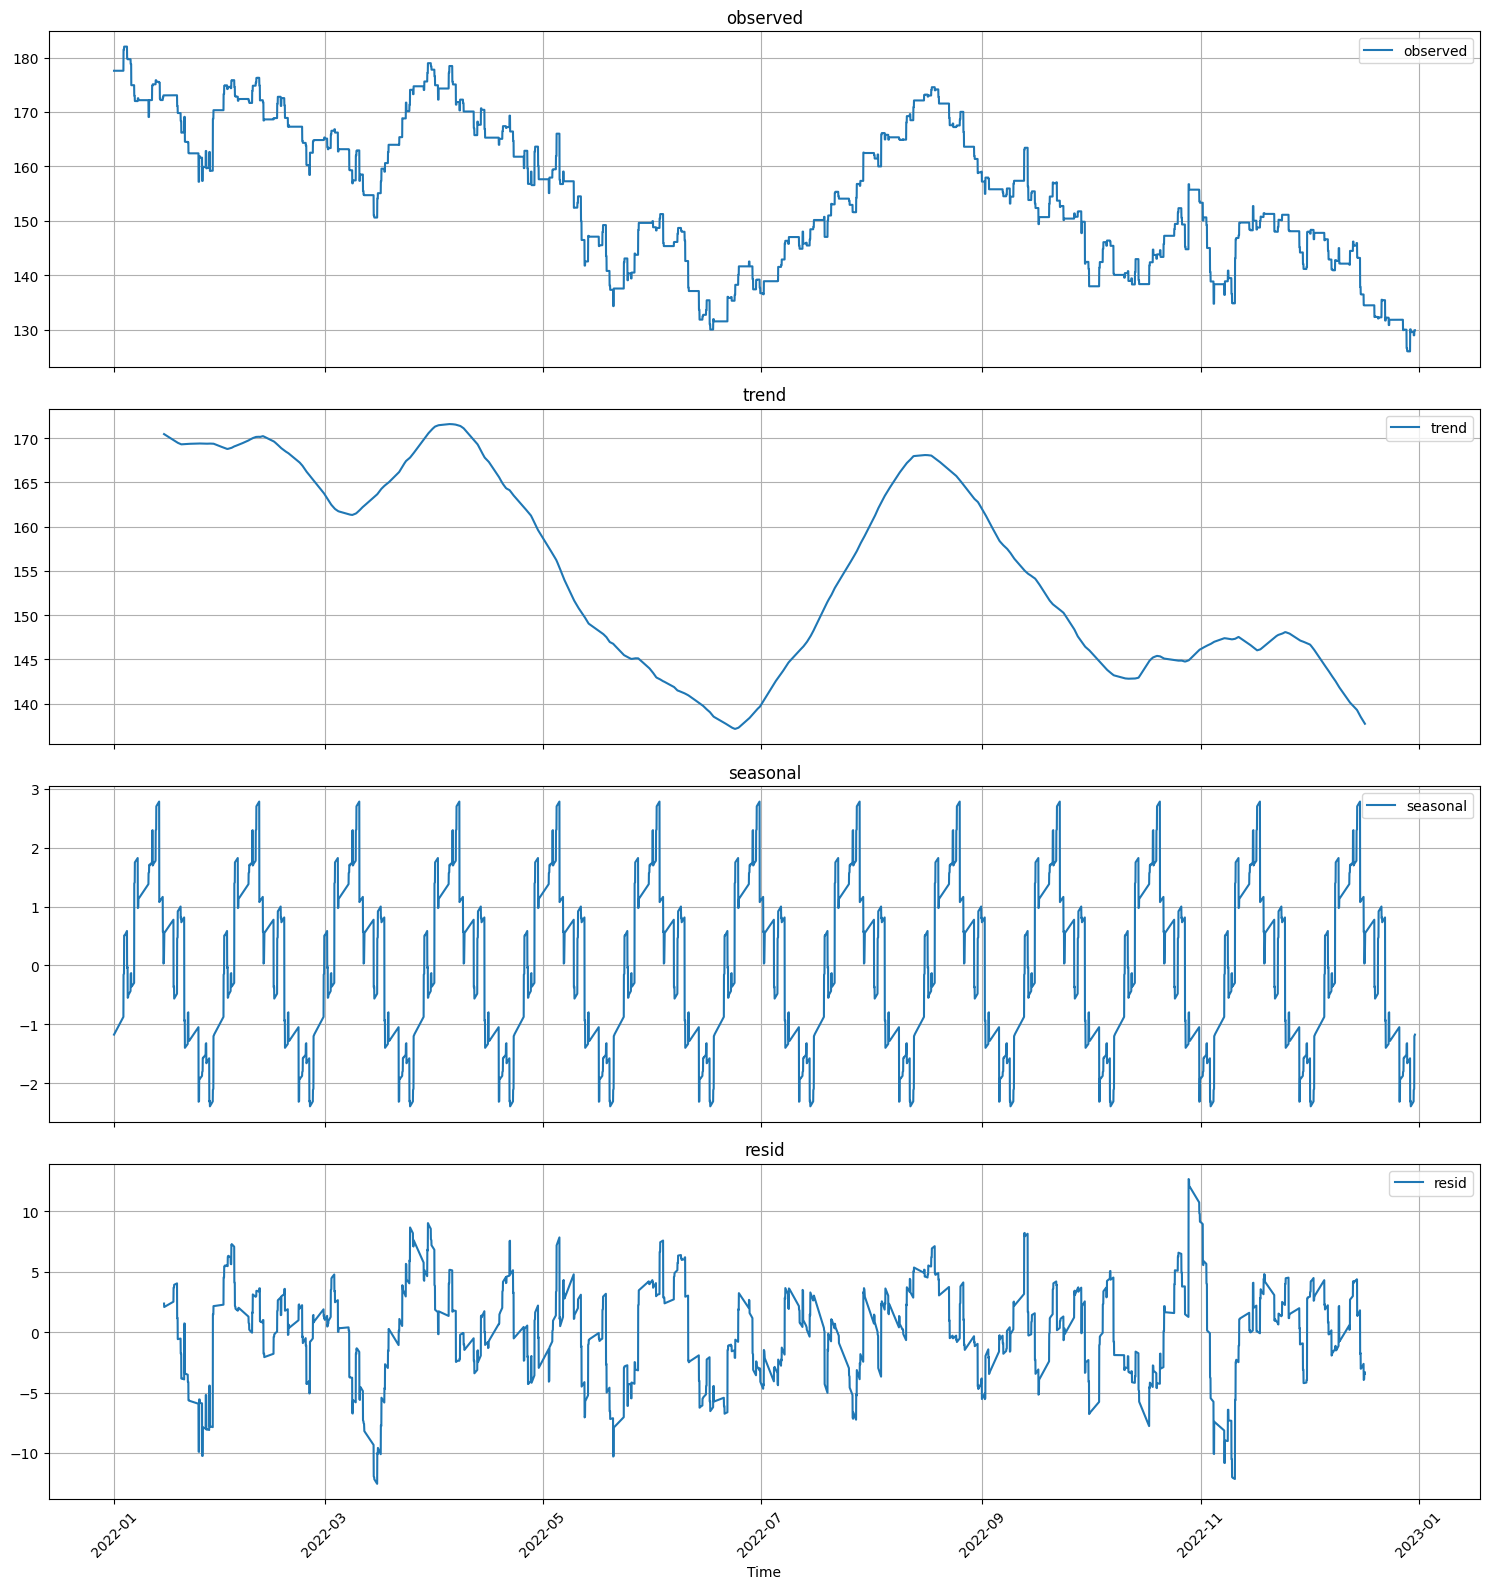

In [7]:
for ts in time_series_process:
    if ts.ticket_name == plot_params.ticket_name and ts.data_column_name == plot_params.data_column_name:
        TimeSeriesPlot.plot_decomposed_data(time_series=ts)

In [8]:
# Генерация моделей для каждого временного ряда
time_series_models: List[TimeSeries] = (
    TimeSeriesPipeline.model_generate_parallel(params=params, time_series=time_series_process)
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
C:\Users\unico\Desktop\work\repositories\tsml\modules\common.py:58: RuntimeWarning: divide by zero encountered in double_scalars
  self.observation_data),
C:\Users\unico\Desktop\work\repositories\tsml\modules\common.py:62: RuntimeWarning: divide by zero encountered in double_scalars
  self.observation_data)
C:\Users\unico\Desktop\work\repositories\tsml\modules\common.py:58: RuntimeWarning: divide by zero encountered in double_scalars
  self.observation_data),
C:\Users\unico\Desktop\work\repositories\tsml\modules\common.py:62: RuntimeWarning: divide by zero encountered in double_scalars
  self.observation_data)
C:\Users\unico\Desktop\work\repositories\tsml\modules\common.py:58: RuntimeWarning: divide by zero encountered in double_scalars
  self.observation_data),
C:\Users\unico\Desktop\work\repositories\tsml\modules\common.py:62: RuntimeWarning: divide by zero encountered in double_scalars
  self.observati

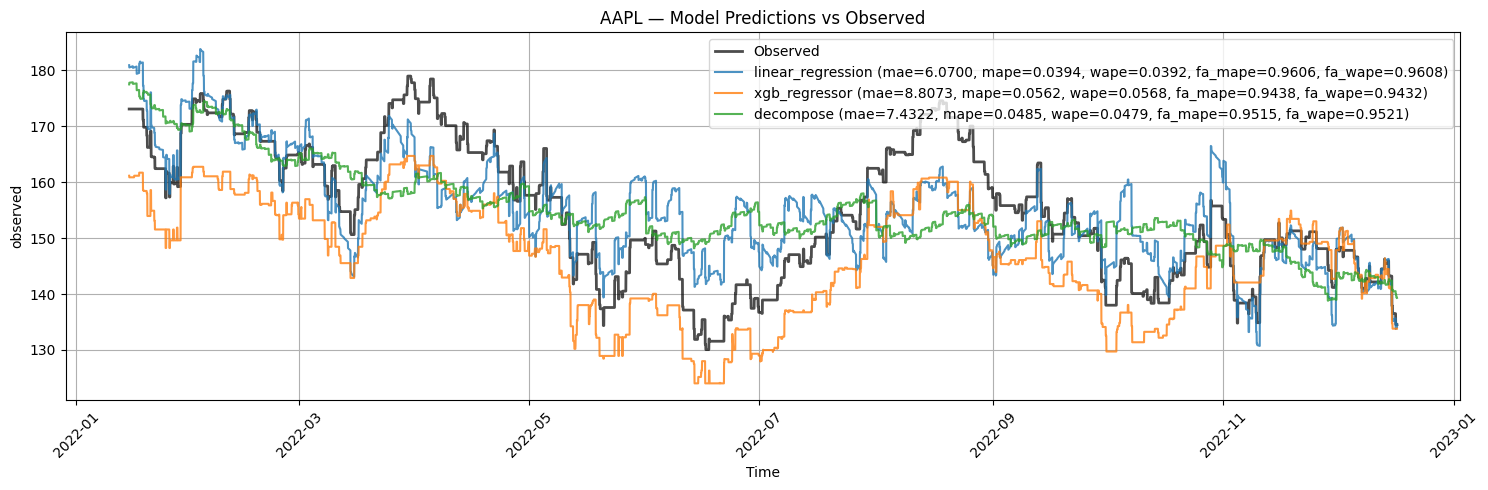

In [9]:
for ts in time_series_models:
    if ts.ticket_name == plot_params.ticket_name and ts.data_column_name == plot_params.data_column_name:
        TimeSeriesPlot.plot_processed_prediction_data(time_series=ts)

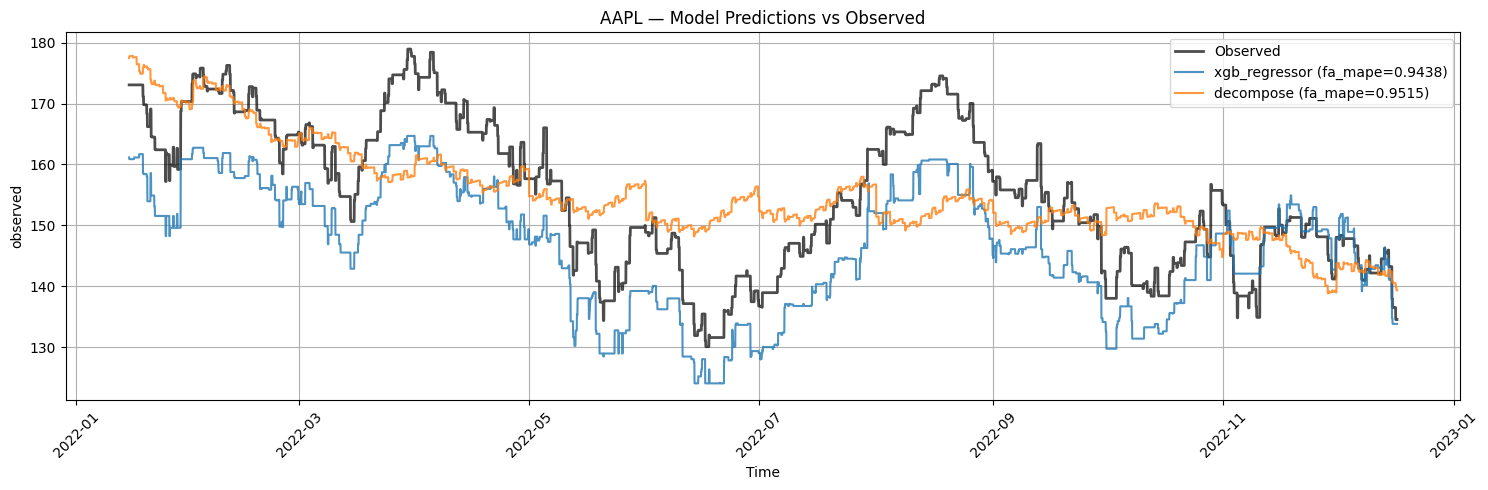

In [10]:
for ts in time_series_models:
    if ts.ticket_name == plot_params.ticket_name and ts.data_column_name == plot_params.data_column_name:
        TimeSeriesPlot.plot_processed_prediction_data(
            time_series=ts,
            metrics_names=plot_params.metrics_names,
            models_types=plot_params.models_types
        )

In [11]:
# Валидация на актуальных данных
params_validate: dr.InputParams = dr.InputParams(
    #reading
    data_directory='data/validate_data',
    tickets_group='NDXT_3',
    file_extension='csv',
    time_column='datetime',
    data_columns=['open', 'close'],
    # processing
    missing_method='rolling',
    rolling_window_size=2,
    target_frequency='H',
    frequency_method='mean',
    anomaly_method='rolling',
    z_threshold=3.0,
    decompose_model='additive',
    decompose_period=24 * 7 * 4,  # дискретизация тренда по месяцам при условии наличия часовых наблюдений
    correlation_method='spearman',
    correlation_threshold=0.3,
    is_feature_selection=False
)

In [12]:
# Инициализация временных рядов
time_series_validate: List[TimeSeries] = TimeSeriesPipeline.time_series_read_parallel(params=params_validate)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [13]:
# Подготовка данных временных рядов
time_series_process_validate: List[TimeSeries] = (
    TimeSeriesPipeline.time_series_process_parallel(params=params_validate, time_series=time_series_validate)
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   6 | elapsed:    1.6s remaining:    3.3s
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    1.6s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:    1.6s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    1.6s finished


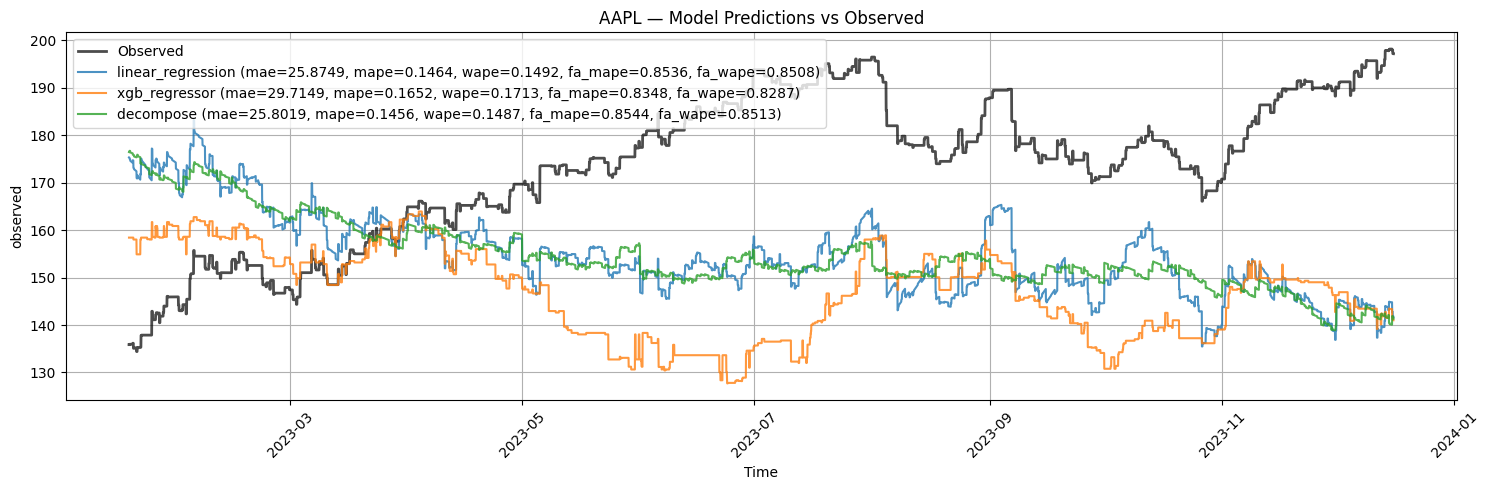

In [14]:
for ts_validate in time_series_process_validate:
    if (
            ts_validate.ticket_name == plot_params.ticket_name
            and ts_validate.data_column_name == plot_params.data_column_name
    ):
        for ts_source in time_series_models:
            if (
                    ts_source.ticket_name == plot_params.ticket_name
                    and ts_source.data_column_name == plot_params.data_column_name
            ):
                TimeSeriesPlot.plot_validate_data(time_series_source=ts_source, time_series_validate=ts_validate)
                break

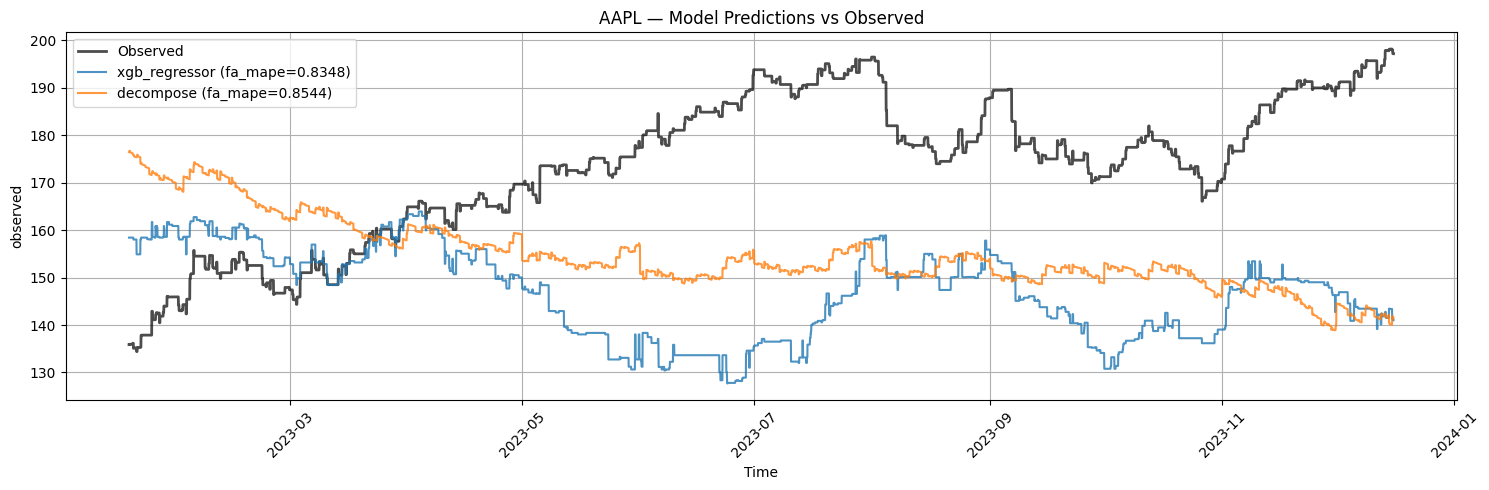

In [15]:
for ts_validate in time_series_process_validate:
    if (
            ts_validate.ticket_name == plot_params.ticket_name
            and ts_validate.data_column_name == plot_params.data_column_name
    ):
        for ts_source in time_series_models:
            if (
                    ts_source.ticket_name == plot_params.ticket_name
                    and ts_source.data_column_name == plot_params.data_column_name
            ):
                TimeSeriesPlot.plot_validate_data(
                    time_series_source=ts_source,
                    time_series_validate=ts_validate,
                    metrics_names=plot_params.metrics_names,
                    models_types=plot_params.models_types
                )
                break